In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
df = pd.read_csv("train_v9rqX0R.csv")
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [48]:
#check null values in each column
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [49]:
#Dropping null values in outlet_size
df.dropna(subset=['Outlet_Size'],inplace=True)

In [50]:
mean=df['Item_Weight'].mean()
df['Item_Weight'].fillna(mean,inplace=True)
df.isnull().sum()

C:\Users\KAVISH\AppData\Local\Temp\ipykernel_22844\3461181817.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Weight'].fillna(mean,inplace=True)


Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [51]:
df.shape

(6113, 12)

In [52]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Item_Fat_Content'] = le.fit_transform(df['Item_Fat_Content'])
df['Item_Type'] = le.fit_transform(df['Item_Type'])
df['Outlet_Size']=le.fit_transform(df['Outlet_Size'])
df['Outlet_Location_Type']=le.fit_transform(df['Outlet_Location_Type'])
df['Outlet_Type']=le.fit_transform(df['Outlet_Type'])

In [53]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,1,0.016047,4,249.8092,OUT049,1999,1,0,1,3735.1380
1,DRC01,5.920,2,0.019278,14,48.2692,OUT018,2009,1,2,2,443.4228
2,FDN15,17.500,1,0.016760,10,141.6180,OUT049,1999,1,0,1,2097.2700
4,NCD19,8.930,1,0.000000,9,53.8614,OUT013,1987,0,2,1,994.7052
5,FDP36,10.395,2,0.000000,0,51.4008,OUT018,2009,1,2,2,556.6088


In [54]:
#check null values in each column
df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [55]:
df.drop(['Item_Identifier','Outlet_Identifier'],axis=1,inplace=True)

In [56]:
df.shape

(6113, 10)

In [57]:
from sklearn.model_selection import train_test_split
train,test = train_test_split (df,test_size=0.3)

x_train= train.drop('Item_Outlet_Sales',axis=1)
y_train = train['Item_Outlet_Sales']

x_test = test.drop('Item_Outlet_Sales',axis=1)
y_test = test['Item_Outlet_Sales']

In [58]:
from sklearn import neighbors
from sklearn.metrics import mean_squared_error
from math import sqrt

model = neighbors.KNeighborsRegressor(n_neighbors=3)
model.fit(x_train,y_train)
pred = model.predict(x_test)
error = sqrt(mean_squared_error(y_test,pred))
error


1349.3949982504969

In [59]:
rmse_val = []
k_list=[]
for K in range(50):
  K=K+1
  model = neighbors.KNeighborsRegressor(n_neighbors=K)

  model.fit(x_train,y_train)
  pred = model.predict(x_test)
  error = sqrt(mean_squared_error(y_test,pred))
  rmse_val.append(error)
  k_list.append(K)
  print('RMSE value for k = ' , K , 'is:', error)


RMSE value for k =  1 is: 1644.9473190417466
RMSE value for k =  2 is: 1421.6520459542778
RMSE value for k =  3 is: 1349.3949982504969
RMSE value for k =  4 is: 1320.7853966936855
RMSE value for k =  5 is: 1299.3834301088252
RMSE value for k =  6 is: 1288.0821863896829
RMSE value for k =  7 is: 1284.00320932838
RMSE value for k =  8 is: 1290.88150279451
RMSE value for k =  9 is: 1290.7962330164949
RMSE value for k =  10 is: 1292.4809915376359
RMSE value for k =  11 is: 1295.884243135735
RMSE value for k =  12 is: 1303.1869807605558
RMSE value for k =  13 is: 1309.0535545699458
RMSE value for k =  14 is: 1321.9902550666905
RMSE value for k =  15 is: 1326.352438904897
RMSE value for k =  16 is: 1328.5019478683932
RMSE value for k =  17 is: 1331.1459871483573
RMSE value for k =  18 is: 1335.473634812453
RMSE value for k =  19 is: 1337.5763616487827
RMSE value for k =  20 is: 1341.2322592192518
RMSE value for k =  21 is: 1343.7035382397266
RMSE value for k =  22 is: 1345.4413925645367
RMSE

In [60]:
best_rmse_score = min(rmse_val)
best_k = k_list[rmse_val.index(best_rmse_score)]
print("Optimal value for k = ", best_k , "with least RMSE =", best_rmse_score)

Optimal value for k =  7 with least RMSE = 1284.00320932838


Text(0, 0.5, 'RMSE')

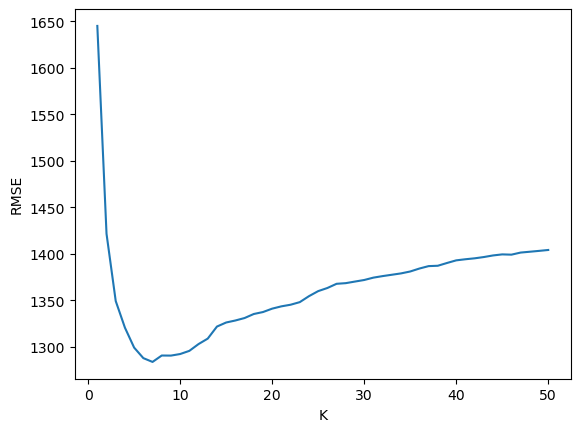

In [61]:
plt.plot(k_list,rmse_val)
plt.xlabel('K')
plt.ylabel('RMSE')